как улучшить данные до обработки? мы знаем что поле "зеленое" и занимает большую часть кадра
мы знаем что линии белые. также известно что линии "узкие" и не содержат внутри других цветов: если взять точки 
 поэтому есть смысл рассматривать переходы только между белым и зеленым цветом.




In [62]:
# %pip install opencv-python imageio 


In [63]:
# filed detection
import cv2
from numba.experimental import jitclass
# from imageio.core.imopen import imopen
from numpy.ma.core import shape
import numpy as np

# img = cv2.imread('../tmp/v5_bacground.png', cv2.IMREAD_COLOR)  # road.png is the filename

def init_image_to_process():
    input_video_path = "../materials_part1/2024-11-18 17-53-16.mkv"#"../2024-11-18 17-53-16.mkv"  #"F:\\Videos\\2024-11-18 17-59-05.avi"  #"F:\\Videos\\2024-11-18 17-49-57.mkv"  #"F:\\Videos\\2024-11-18 17-59-05.avi"
    
    cap = cv2.VideoCapture(input_video_path)
    
    from cut_image import get_cut_frame_from_frame
    
    ret, image = cap.read()
    for _ in range(100):
        ret, image = cap.read()
        if not ret:
            pass
        
    image = get_cut_frame_from_frame(image, 2)
    image = cv2.rotate(image, cv2.ROTATE_180)
    img_tmp = cv2.blur(image, (3, 3))
    cv2.imwrite("../tmp/hehe4.png", img_tmp)

def init_image_to_process2():
    input_img = "../datasets/test/cam0/4.png"
    
    image = cv2.imread(input_img)
    image = cv2.rotate(image, cv2.ROTATE_180)
    # img_tmp = cv2.blur(image, (3, 3))
    cv2.imwrite("../tmp/hehe4.png", image)

init_image_to_process2()



# image = cv2.blur(image, (3, 3))
# image = cv2.blur(image, (3, 3))
# img = cluster_and_recolor(image, 13, 3, top_n=2, binary=True)  #13 3 2 // 30 3 6 // 20 3 3
# print(img)
# img = cluster_and_recolor(img,4)
# cv2.imshow('lanes', img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()


from sklearn.cluster import KMeans


# flat = img.flatten()
def multiply_list(data):
    tmp = 1
    for i in data:
        tmp *= i
    return tmp


def cluster_and_recolor(img, n_clusters, mode: int = 1, top_n=None, binary=False):
    flat = img.reshape((multiply_list(img.shape) // 3, 3))

    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=3).fit(flat)

    cluster_color_centers = list()
    for i in kmeans.cluster_centers_:
        clr = list()
        for j in i:
            clr.append(int(j))
        cluster_color_centers.append(clr)
    cluster_color_centers = np.array(cluster_color_centers)
    # print(img, "hehe", flat, type(img), "hehe", cluster_color_centers)

    unflat = kmeans.labels_.reshape(img.shape[:-1]).astype(np.uint8)

    if mode == 1:
        return unflat * (255 // n_clusters)
    elif mode == 2 or mode == 3:
        sizes = [0] * len(cluster_color_centers)
        for i in kmeans.labels_:
            sizes[i] += 1
        tmp_sizes = list()
        for num, i in enumerate(sizes):
            tmp_sizes.append((-i, num))
        tmp_sizes = sorted(tmp_sizes)
        remap = [0] * len(sizes)
        for num, i in enumerate(tmp_sizes):
            remap[i[1]] = num
        if mode == 3:
            start_clr = cluster_color_centers[tmp_sizes[0][1]]
            size = tmp_sizes[0][0]
            if top_n is None:
                top_n = 0
            seen = [tmp_sizes[0][1]]
            for i in range(top_n):
                nearest = 0
                dist = np.inf
                size_tmp = 0
                for j in range(n_clusters):
                    if tmp_sizes[j][1] not in seen and np.linalg.norm(
                            start_clr - cluster_color_centers[tmp_sizes[j][1]]) < dist:
                        dist = np.linalg.norm(start_clr - cluster_color_centers[tmp_sizes[j][1]])
                        nearest = tmp_sizes[j][1]
                        size_tmp = tmp_sizes[j][0]
                seen.append(nearest)
                #start_clr = size * (start_clr / (size_tmp + size)) + cluster_color_centers[nearest] * (size_tmp / (size_tmp + size))
                size += size_tmp
            for j in seen:
                remap[j] = seen[0]
        for i in range(len(unflat)):
            for j in range(len(unflat[i])):
                if top_n is None or (mode == 3 and not binary):
                    unflat[i][j] = remap[unflat[i][j]]
                elif binary and mode == 3:
                    if remap[unflat[i][j]] == remap[tmp_sizes[0][1]]:
                        unflat[i][j] = 255
                    else:
                        unflat[i][j] = 0
                elif top_n > remap[unflat[i][j]]:
                    unflat[i][j] = 255
                else:
                    unflat[i][j] = 0
        if top_n is None or mode == 3:
            return unflat * (255 // n_clusters)
        else:
            return unflat
    elif mode == 4:
        for i in range(img.shape[0]):
            for j in range(img.shape[1]):
                img[i][j] = cluster_color_centers[unflat[i][j]]
        return img


# image = cv2.blur(image, (3, 3))
# image = cv2.blur(image, (3, 3))
# img = cluster_and_recolor(image, 13, 3, top_n=2, binary=True)  #13 3 2 // 30 3 6 // 20 3 3
# print(img)
# img = cluster_and_recolor(img,4)
# cv2.imshow('lanes', img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

In [67]:
#lines detection
from image_tuner import rgb_tune_test, tune_from_params, rgb_tune_from_params
import numpy as np
import math
from numba import jit
import sklearn.cluster as skcl
from scipy.spatial import ConvexHull
from sklearn.linear_model import LinearRegression

import cv2

# white_color_img = tune_test("../tmp/hehe4.png")  #69 0 153 191 248 255
img_tmp = cv2.imread("../tmp/hehe4.png")
img_tmp = cv2.resize(img_tmp,(700,700)) # we should resize to some standart resolution so in linesearch arguments are the same, because otherwise it finds shorter lines 
# img_tmp = cv2.imread("/root/Downloads/corridor_field.jpg")
green_color_img = cv2.blur(img_tmp, (3, 3))
green_color_img = cluster_and_recolor(green_color_img, 12, 3, top_n=2, binary=True)  #13 3 2 // 30 3 6 // 20 3 3
# ##########################################################
# Загрузка изображения
image = green_color_img

# Бинаризация изображения
_, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

# Поиск контуров
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Создание маски
mask = np.zeros_like(image)

# Пороги для фильтрации
aspect_ratio_min = 0.2  # Минимальное аспектное соотношение
aspect_ratio_max = 5.0  # Максимальное аспектное соотношение
area_min = 100          # Минимальная площадь

# Обработка контуров
for contour in contours:
    # Получаем размеры ограничивающего прямоугольника
    x, y, w, h = cv2.boundingRect(contour)

    # Вычисляем аспектное соотношение
    aspect_ratio = float(w) / h if h != 0 else 0

    # Вычисляем площадь
    area = cv2.contourArea(contour)

    # Если это прямоугольник, заливаем его
    if aspect_ratio_min < aspect_ratio < aspect_ratio_max and area > area_min:
        cv2.drawContours(mask, [contour], -1, 255, -1)

# Применяем маску к изображению
result = image.copy()
result[mask == 255] = 255
green_color_img = result
# ##########################################################
# cv2.imshow('ss', green_color_img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
white_color_img = cv2.blur(img_tmp, (5, 5))
white_color_img = tune_from_params(white_color_img, 33, 0, 143, 181, 76, 255)
# cv2.imshow('ss', white_color_img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

# ##########################################################
# Загрузка изображения
image = white_color_img

# Бинаризация изображения
_, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

# Поиск контуров
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Создание маски
mask = np.zeros_like(image)

# Пороги для фильтрации
aspect_ratio_min = 0.2  # Минимальное аспектное соотношение
aspect_ratio_max = 5.0  # Максимальное аспектное соотношение
area_min = 100          # Минимальная площадь

# Обработка контуров
for contour in contours:
    # Получаем размеры ограничивающего прямоугольника
    x, y, w, h = cv2.boundingRect(contour)

    # Вычисляем аспектное соотношение
    aspect_ratio = float(w) / h if h != 0 else 0

    # Вычисляем площадь
    area = cv2.contourArea(contour)

    # Если это прямоугольник, заливаем его
    if aspect_ratio_min < aspect_ratio < aspect_ratio_max and area > area_min:
        cv2.drawContours(mask, [contour], -1, 255, -1)

# Применяем маску к изображению
result = image.copy()
result[mask == 255] = 255
white_color_img = result
# cv2.imshow('green image', green_color_img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
# rgb_tune_test("/root/Downloads/corridor_field.jpg")
# green_color_img = cluster_and_recolor(green_color_img, 13, 3, top_n=2, binary=True)  #13 3 2 // 30 3 6 // 20 3 3
# white_color_img = tune_from_params(img_tmp, 33, 0, 143, 181, 76, 255)
# green_color_img = tune_from_params(img_tmp,23,113,58,36,255,154)
# white_color_img = rgb_tune_from_params(img_tmp,57,104,117,117,124,137)
# print(white_color_img.shape,len(white_color_img),len(white_color_img[0]))
# cv2.imshow('white image', white_color_img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

@jit
def get_result_edges(white_color_img_i, green_color_img_i):# _i for internal
    # result_edges_i = white_color_img_i * 0
    result_edges_i = np.zeros(white_color_img_i.shape, dtype="uint8")
    for i in range(1, len(white_color_img_i) - 1):
        for j in range(1, len(white_color_img_i[i]) - 1):
            seen_white = 0
            seen_green = 0
            bad = 0
            for k in (-1, 0, 1):
                for t in (-1, 0, 1):
                    if green_color_img_i[i + k][j + t] > 200:
                        seen_green += 1
                    if white_color_img_i[i + k][j + t] > 200:
                        seen_white += 1
                    if green_color_img_i[i + k][j + t] <= 200 and white_color_img_i[i + k][j + t] <= 200:
                        bad += 1
            if seen_white > 1 and seen_green > 2 and (seen_white + seen_green) < 14:
                # print("lane")
                result_edges_i[i][j] = 255
    return  result_edges_i
result_edges = get_result_edges(white_color_img,green_color_img)
print("end prep")

analysis = cv2.connectedComponentsWithStats(result_edges,
                                            4,
                                            cv2.CV_32S)
(totalLabels, label_ids, values, centroid) = analysis
areas = list()
for i in values:
    areas.append(i[cv2.CC_STAT_AREA])
areas = sorted(areas, reverse=True)
output = np.zeros(result_edges.shape, dtype="uint8")
for i in range(1, totalLabels):
    area = values[i, cv2.CC_STAT_AREA]

    if area >= areas[30]:
        # Labels stores all the IDs of the components on the each pixel 
        # It has the same dimension as the threshold 
        # So we'll check the component 
        # then convert it to 255 value to mark it white 
        componentMask = (label_ids == i).astype("uint8") *255#* int(i/totalLabels*255)
        # print(i/totalLabels)

        # Creating the Final output mask 
        output = cv2.bitwise_or(output, componentMask)
    # print (analysis)
cv2.imwrite("../tmp/hehe6.png",output)
# cv2.imshow('lanes', output)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

segments = cv2.HoughLinesP(output, 1, math.pi / 180, 80, 30, 40) #cv2.HoughLinesP(image, rho, theta, threshold, minLineLength, maxLineGap)
# segments = cv2.HoughLinesP(output, 1, math.pi / 180, 80, 60, 40) #cv2.HoughLinesP(image, rho, theta, threshold, minLineLength, maxLineGap)
# print(segments.shape,segments)
segments = segments.reshape((len(segments), 2, 2))

# segments[i] = sorted(segments[i])
lines = list()
if False:  #clusterization method   #todo redo segments from vec<int,4> to vec<vec<int,2>,2>
    segm_by_direction_and_sp = list()
    for i_tmp in segments:
        i = i_tmp[0]
        x = i[2] - i[0]
        y = i[3] - i[1]
        if True:
            len_xy = math.sqrt(x * x + y * y)
            x /= len_xy
            y /= len_xy
        if x < 0:
            x *= -1
            y *= -1
        zero = (0, 0)
        if abs(x) > abs(y):
            c1 = i[0] / x
            zero = (0, i[1] - y * c1)
        else:
            c1 = i[1] / y
            zero = (i[0] - x * c1, 0)
        segm_by_direction_and_sp.append((x * 1000, y * 1000, zero[0], zero[1]))
    segm_by_direction_and_sp = np.array(segm_by_direction_and_sp)
    # clusters = skcl.OPTICS(min_samples=4).fit(segm_by_direction_and_sp)
    # clusters = skcl.DBSCAN(min_samples=2).fit(segm_by_direction_and_sp)
    clusters = skcl.HDBSCAN(min_samples=2).fit(segm_by_direction_and_sp)
    # clusters = KMeans(n_clusters=10).fit(segm_by_direction_and_sp)
    centers_of_clusters = dict()
    for i in range(len(segm_by_direction_and_sp)):
        if clusters.labels_[i] not in centers_of_clusters.keys():
            centers_of_clusters[clusters.labels_[i]] = [np.linalg.norm(segments[i][0][:1] - segments[i][0][2:])]
            # print(type(segm_by_direction_and_sp[i].tolist()),,centers_of_clusters[clusters.labels_[i]])
            centers_of_clusters[clusters.labels_[i]].extend(
                (segm_by_direction_and_sp[i] * np.linalg.norm(segments[i][0][:1] - segments[i][0][2:])).tolist())
        else:
            centers_of_clusters[clusters.labels_[i]][0] += np.linalg.norm(segments[i][0][:1] - segments[i][0][2:])
            for j in range(len(segm_by_direction_and_sp[i])):
                centers_of_clusters[clusters.labels_[i]][j + 1] += segm_by_direction_and_sp[i][j] * np.linalg.norm(
                    segments[i][0][:1] - segments[i][0][2:])
    for i in centers_of_clusters.values():
        # print(i)
        # i = [1]
        # i.extend(i_tmp)
        lines.append([[int((i[-2] - 1000 * i[1]) / i[0]), int((i[-1] - 1000 * i[2]) / i[0]),
                       int((i[-2] + 1000 * i[1]) / i[0]), int((i[-1] + 1000 * i[2]) / i[0])]])

#idea: if 2 segments are on line then area on 4 points is minimal


if False:
    for i in range(len(segments)):  #sorted so segms are from x1 to x2 where x1<x2 or x1==x2 and y1<y2
        if segments[i][0][0] < segments[i][1][0]:
            segments[i] = np.array([segments[i][1], segments[i][0]])
        elif segments[i][0][0] == segments[i][1][0] and segments[i][0][1] < segments[i][1][1]:
            segments[i] = np.array([segments[i][1], segments[i][0]])

    st = set()
    for i in segments:
        st.add(tuple(i.reshape((4)).tolist()))
    while True:
        # concatinating segments by using best start and best end points while area metric allows it
        first_best = second_best = None
        best_area = 0
        for i_tmp in st:
            for j_tmp in st:
                i = np.array(i_tmp)
                j = np.array(j_tmp)
                if (i != j).any():
                    area = 0
                    points = np.array([i, j]).reshape((4, 2))
                    for i in range(len(points)):
                        area += np.cross(points[i], points[(i + 1) % len(points)])

                    if first_best is None:
                        first_best = i
                        second_best = j
                        best_area = area
                    else:
                        if best_area > area:
                            best_area = area
                            first_best = i
                            second_best = j
        if area > 500:
            break

        points = np.array([first_best, second_best]).reshape((2, 4))
        line = LinearRegression().fit(points[0], points[1])
        start = (0, line.intercept_)
        direction = (1, line.coef_)


        def project_point(point, start_line, direction_line):
            point -= start_line
            sk = 0
            len_line = 0
            for i in range(len(line)):
                len_line += direction_line[i] ** 2
                sk += direction_line[i] * point[i]
            sk /= len_line
            return start_line + direction_line * sk


        result = (0, 0)
        if first_best[0] < second_best[0]:
            result[0] = first_best[0]
        else:
            result[0] = second_best[0]
        if first_best[0] > second_best[0]:
            result[1] = first_best[1]
        else:
            result[1] = second_best[1]
        result[0] = project_point(result[0], start, direction)
        result[1] = project_point(result[1], start, direction)
        st.remove(first_best)
        st.remove(second_best)
        st.add(np.array(result))
    lines = list(st)

#idea 3: same as idea 2, but using this metric in dbscan
labels = 0
n_clusters = 0
@jit
def cross2d(x, y):
    return np.array([x[..., 0] * y[..., 1] - x[..., 1] * y[..., 0]])

if True:
    @jit
    def custom_distance_v1(a: np.array, b: np.array):  # works iff a and b goes into different directions
        a = a.reshape((2, 2))
        b = b.reshape((2, 2))
        points = [a[0], a[1], b[0], b[1]]
        sum = cross2d(points[-1], points[0])
        for i in range(1, len(points)):
            sum += cross2d(points[i - 1], points[i])
        return np.linalg.norm(sum)  #eps = 10

    @jit
    def custom_distance_v2(a: np.array, b: np.array):
        a = a.reshape((2, 2))
        b = b.reshape((2, 2))
        points = [a[0], a[1], b[0], b[1]]
        sum = cross2d(points[-1], points[0])
        for i in range(1, len(points)):
            sum += cross2d(points[i - 1], points[i])
        points[0], points[1] = points[1], points[0]
        sum2 = cross2d(points[-1], points[0])
        for i in range(1, len(points)):
            sum2 += cross2d(points[i - 1], points[i])
        return max(np.linalg.norm(sum), np.linalg.norm(sum2))  #eps = 100

    @jit
    def custom_distance_v3(a: np.array, b: np.array):
        a = a.reshape((2, 2))
        b = b.reshape((2, 2))
        points = [a[0], a[1], b[0], b[1]]
        sum = cross2d(points[-1], points[0])
        for i in range(1, len(points)):
            sum += cross2d(points[i - 1], points[i])
        points[0], points[1] = points[1], points[0]
        sum2 = cross2d(points[-1], points[0])
        for i in range(1, len(points)):
            sum2 += cross2d(points[i - 1], points[i])
        return max(np.linalg.norm(sum), np.linalg.norm(sum2)) / (
                    np.linalg.norm(a[0] - a[1]) + np.linalg.norm(b[0] - b[1]))  #eps = 5


    # print(segments)
    clustering = skcl.DBSCAN(eps=5, min_samples=1, metric=custom_distance_v3).fit(
        segments.reshape((segments.shape[0], 4)))
    labels = clustering.labels_
    n_clusters = len(np.unique(labels)) - (1 if -1 in labels else 0)
    # print("labels,cluster_n ",labels,n_clusters)


def add_up_segments_v1(data: np.array):
    data = data.astype(np.float64)

    #prepare
    # def is_same_direction(a,b):
    #     v1 = np.cross(b-a[0],a[1]-a[0])/np.linalg.norm(a[1]-a[0])*(a[1]-a[0]).reshape((1,2))
    #     delta = np.linalg.norm((a[1]-a[0])-(v1[1]-v1[0]))
    #     return delta<1e-5
    # def is_same_direction_v2(a,b):
    #     v1 = np.cross(b-a[0],a[1]-a[0])/np.linalg.norm(a[1]-a[0])
    #     delta = 1-(v1[1]-v1[0])
    #     return delta<1e-5
    def is_same_direction_v3(a, b):
        return np.dot(a[1] - a[0], b[1] - b[0]) > 0

    # print(is_same_direction_v3(np.array([[1,2],[3,4]]),np.array([[9,10],[7,8]])))#false
    # print(is_same_direction_v3(np.array([[1,2],[3,4]]),np.array([[5,6],[7,8]])))#true
    for i in range(1, len(data)):
        if not is_same_direction_v3(data[0], data[i]):
            data[i][0], data[i][1] = data[i][1], data[i][0]
    sum_weight = np.linalg.norm(data[0][1] - data[0][0])
    sum_direction = data[0][1] - data[0][0]
    avg_point = (data[0][0] + data[0][1]) * sum_weight
    for i in range(1, len(data)):
        tmp_w = np.linalg.norm(data[i][1] - data[i][0])
        sum_direction += data[i][1] - data[i][0]
        avg_point += (data[i][0] + data[i][1]) * tmp_w
        sum_weight += tmp_w
    sum_direction /= sum_weight
    avg_point /= sum_weight * 2
    start = 0
    end = 0
    for i in range(len(data)):
        start = min(start, np.dot(sum_direction, data[i][0] - avg_point))
        end = max(end, np.dot(sum_direction, data[i][1] - avg_point))
    return (np.array([start * sum_direction, end * sum_direction]) + avg_point).astype(np.int32)


grouped = dict()
for i in range(len(segments)):
    if labels[i] not in grouped.keys():
        grouped[labels[i]] = [segments[i]]
    else:
        grouped[labels[i]].append(segments[i])
if True:
    new_segments = list()
    for i in grouped.values():
        new_segments.append(add_up_segments_v1(np.array(i)))
    segments = new_segments


end prep


In [68]:

# matrix = homography_matrix(segments)        

# print(white_color_img)
from homography_matrix import homography_matrix_v2

In [69]:

# output_2 = cv2.warpPerspective(img_tmp,matrix,(3000,3000))
output_2 = output
print(output_2.shape)
# segments = cv2.perspectiveTransform(np.array(segments).reshape((len(segments)*2,1,2)).astype(np.float32),matrix).reshape((len(segments),2,2)).astype(int)+np.array((500,500))
# print(segments)
# print(lines)
output_2 //= 5
for i in range(len(segments)):
    output_2 = cv2.line(output_2, segments[i][0], segments[i][1], 255)  # 40 kmeans is good

cv2.imshow('lanes', output_2)
cv2.waitKey(0)
cv2.destroyAllWindows()

(700, 700)


In [70]:

# segments = list()
# tttmpsegm = segments
# segments = segments[:2]
# print(segments)
# print(segments)
# segments = [np.array([[0,0],[0,100]]),np.array([[1,0],[2,100]])]
# segments = [np.array([[0,0],[100,0]]),np.array([[0,1],[100,2]])]

# segments = list()
# for i in range(10):
#     i *=30
#     segments.append(np.array([[0,i*1],[-1000,3*i]])+np.array([1000,0]))
# for i in range(10):
#     i*=30
#     segments.append(np.array([[i*1,0],[3*i,1000]]))#+np.array([0,1000]))

from horizon_point import get_horizon_point,horizon_point_optimization_loss_v2

from scipy.optimize import minimize
hor_points = list()
segs_groups = list()
if True:
    # print(len(segments))
    to_remove = set()
    for i in range(4):
        print('-'*100)
        new_segments = list()
        rev_map = dict()
        for j in range(len(segments)):
            if j not in to_remove:
                rev_map[len(new_segments)] = j
                new_segments.append(segments[j].astype(np.float64))
        val,point,segs_tmp = get_horizon_point(new_segments,9e-1)# here is setting for eps
        #todo: find better position: loss: angle from direction of line multiplied by length of segment, sum of this values should be minimized.
        segs = set()
        for j in segs_tmp:
            segs.add(rev_map[j])
        segs_groups.append(segs)
        hor_points.append(point)
        print(val,segs)
        segs_real = list()
        for j in segs:
            segs_real.append(segments[j].astype(np.float64))
        print("before opt: ",point,horizon_point_optimization_loss_v2(point,segs_real))
        opt_res = minimize(horizon_point_optimization_loss_v2,point,segs_real, method = 'Nelder-Mead')
        # print(opt_res)
        point = opt_res.x
        # print(point,type(point))
        print("after opt: ",point,horizon_point_optimization_loss_v2(point,segs_real))
        for j in segs:
            to_remove.add(j)
    print(hor_points)

# segments = tttmpsegm

            








----------------------------------------------------------------------------------------------------
6 {1, 2, 3, 5, 6, 10}
before opt:  [14858.53780036 -2028.2832251 ] 5.960447324738538
after opt:  [13855.85862423 -1827.31825451] 4.8210962136210505
----------------------------------------------------------------------------------------------------
3 {8, 4, 7}
before opt:  [ 293.61168248 -343.01569849] 0.8187699959402641
after opt:  [ 293.5878444  -339.37155526] 0.20936124058248312
----------------------------------------------------------------------------------------------------
2 {0, 9}
before opt:  [313.37756482 619.09226491] 0.6077833332300667
after opt:  [313.53979707 619.04130276] 2.1243642268543135e-05
----------------------------------------------------------------------------------------------------
0 set()
before opt:  [0 0] 0
after opt:  [0. 0.] 0
[array([14858.53780036, -2028.2832251 ]), array([ 293.61168248, -343.01569849]), array([313.37756482, 619.09226491]), array([0, 0

/home/alice/Desktop/Camera-accuracy-studies/utils/horizon_point/point_optimization.py:29: RuntimeWarning: invalid value encountered in arccos
  ans += np.tan(np.abs(np.arccos(np.abs(np.dot(direction,direction2)))))*length


In [85]:
# output_2 = cv2.warpPerspective(img_tmp,matrix,(3000,3000))
output_2 = np.copy(output)
print(output_2.shape)
# segments = cv2.perspectiveTransform(np.array(segments).reshape((len(segments)*2,1,2)).astype(np.float32),matrix).reshape((len(segments),2,2)).astype(int)+np.array((500,500))
# print(segments)
# print(lines)
output_2 *=0
for i in range(len(segs_groups)):
    for j in segs_groups[i]:
        output_2 = cv2.line(output_2, segments[j][0], segments[j][1], 255*(1-i/(len(segs_groups)*2)))
# print(output_2.shape,np.array(output_2.shape)//2)
mat,mask = homography_matrix_v2(hor_points[1],hor_points[0],np.array(output_2.shape)//2)

new_hompgraphy_matrix = 0

def convert_by_homography_mat(point,mat):
    new_point = np.matmul(mat,np.concatenate([point,np.array([1])]))
    new_point/=new_point[2]
    return new_point[:2]
    
# print(mat)
if True:#transforming points
    print("-----------------------------transformation of points--------------------------")
    new_points_after_perspective_transform = list()
    print(f"transformed with matrix using matmul: {mat}")
    for i in segments:
        # new_point = np.matmul(mat,np.concatenate([i[0],np.array([1])]))
        # new_point/=new_point[2]
        # new_point2 = np.matmul(mat,np.concatenate([i[1],np.array([1])]))
        # new_point2/=new_point2[2]
        # new_points_after_perspective_transform.append([new_point[:2],new_point2[:2]])
        # next line is beautified previous:
        new_points_after_perspective_transform.append([convert_by_homography_mat(j,mat) for j in i])
    avg = np.array([0,0]).astype(np.float64)
    for i in new_points_after_perspective_transform:
        avg+=i[0]+i[1]
    avg/=(2*len(new_points_after_perspective_transform))
    print(f"moved by -average: {-avg}")
    max_diff = 0
    target_max_diff = np.linalg.norm(np.array(output_2.shape)/2)
    for i in range(len(new_points_after_perspective_transform)):
        new_points_after_perspective_transform[i]-=avg
        max_diff = max(max_diff,np.linalg.norm(new_points_after_perspective_transform[i]))

    print(f"then scaled with coeff: {target_max_diff/max_diff}, i.e. by max diff of current point and max axis")
    for i in range(len(new_points_after_perspective_transform)):
        new_points_after_perspective_transform[i]*=target_max_diff/max_diff
        new_points_after_perspective_transform[i]+=np.array([output_2.shape[1],output_2.shape[0]])/2
    print(f"then moved by {np.array([output_2.shape[1],output_2.shape[0]])/2}, i.e. by half of image size")
    output_2*=0
    print(new_points_after_perspective_transform)
    for i in new_points_after_perspective_transform:
        output_2 = cv2.line(output_2, list(map(int,i[0])), list(map(int,i[1])), 255)
    black_lines = output_2.copy()
    # output_2 = cv2.resize(output_2,(700,700))
    cv2.imshow('l', output_2)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    def convert_from_params(point:np.ndarray,mat:np.ndarray,move1:np.ndarray,scale:np.ndarray,move2:np.ndarray):
            point = np.matmul(mat,np.concatenate([point,np.array([1])]))
            point/=point[2]
            point = point[:2]
            point-=move1
            point*=scale
            point+=move2
            return point

    def convert_inverse_from_params(point:np.ndarray,inv_mat:np.ndarray,move1:np.ndarray,scale:np.ndarray,move2:np.ndarray):
            point-=move2
            point/=scale
            point+=move1
            point = np.matmul(inv_mat,np.concatenate([point,np.array([1])]))
            point/=point[2]
            point = point[:2]
            return point

    def get_new_hompgraphy_mat(old_points:np.ndarray,mat:np.ndarray,move1:np.ndarray,scale:np.ndarray,move2:np.ndarray):
        new_points= list()
        for i in range(len(old_points)):
            new_points.append(convert_from_params(old_points[i],mat,move1,scale,move2))
        return cv2.findHomography(old_points,np.array(new_points))[0]

    new_hompgraphy_matrix = get_new_hompgraphy_mat(homography_matrix_v2(hor_points[1],hor_points[0],np.array(output_2.shape)//2,True)[0],mat,avg,target_max_diff/max_diff,np.array([output_2.shape[1],output_2.shape[0]])/2)

if True:
    output_2 = cv2.imread("../tmp/hehe6.png")
    print("new hom matrix",new_hompgraphy_matrix)

    output_2 = cv2.warpPerspective(output_2, new_hompgraphy_matrix,(output_2.shape[1],output_2.shape[0]))
    # output_2 = cv2.resize(output_2,(700,700))
    cv2.imwrite("../tmp/hehe7.png",output_2)
    cv2.imshow('lanes', output_2)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

(700, 700)
hor points:  [ -56.38831752 -693.01569849] [14508.53780036 -2378.2832251 ]
h and p3 1089.5384862099136 694.9039565524807 [ -79.87252913 -690.29840498]
839.1678044946065 0.6916340849151378
[[1343.37239121  235.05961382]
 [-643.37239121  464.94038618]
 [ 315.24797206   49.65556718]
 [ 466.47842627 1356.66490403]] [[747.34895649 304.02384553]
 [-47.34895649 395.97615447]
 [311.41829139  16.55754857]
 [379.71581832 606.8189866 ]] [[ 0.08723195  0.99618803]
 [-0.99618803  0.08723195]] 0.6916340849151378
-----------------------------transformation of points--------------------------
transformed with matrix using matmul: [[ 2.69102520e-01  2.54509144e+00 -1.92717981e+02]
 [-7.72581033e-01  1.19728719e+00  6.43602801e+02]
 [ 3.74405249e-04  3.23579817e-03  1.00000000e+00]]
moved by -average: [-380.45446157 -303.71304954]
then scaled with coeff: 1.4892997817089304, i.e. by max diff of current point and max axis
then moved by [350. 350.], i.e. by half of image size
[array([[340.909762

In [89]:
#prepare image for circle search: remove found lines

img = cv2.imread('../tmp/hehe7.png')
for i in segments:
    i = [convert_by_homography_mat(j,mat) for j in i]
    img = cv2.line(img, list(map(int,i[0])), list(map(int,i[1])), 127,10)
cv2.imshow('lanes', img)
cv2.waitKey(0)
cv2.destroyAllWindows()
cv2.imwrite("../tmp/hehe8.png",img)
    


True

hough transform v1 (circles) major idea: it uses only edges

In [75]:
import copy
# from http.cookiejar import debug

import numpy as np
import cv2
from skimage.draw import ellipse
from sympy.physics.units import current

# Read image
img = cv2.imread('../tmp/hehe8.png')

# Convert the image to grayscale
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Find the edges in the image using canny detector
img = cv2.medianBlur(img, 5)
edges = cv2.Canny(img, 50, 200)
# img = cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)
edges = cv2.cvtColor(cv2.imread('../tmp/hehe8.png'),cv2.COLOR_BGR2GRAY)

# Detect points that form a line
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 68, minLineLength=15, maxLineGap=250)
circles = cv2.HoughCircles(edges, cv2.HOUGH_GRADIENT, 1, 100, param1=50, param2=30, minRadius=0, maxRadius=0)
circles = np.uint16(np.around(circles))
print(circles)
for i in circles[0, :]:
    # draw the outer circle
    img = cv2.circle(img, (i[0], i[1]), i[2], 255, 2)
    # draw the center of the circle
    img = cv2.circle(img, (i[0], i[1]), 2, 255, 3)
#lines = cv2.HoughLinesP(edges, 1, np.pi/180, minLineLength=10, maxLineGap=250)
# Draw lines on the image
# for line in lines:
#     x1, y1, x2, y2 = line[0]
#     cv2.line(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
# Show result
cv2.imshow('lanes', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

[[[170 348 162]
  [292 338 170]
  [292 208 302]
  [478 208 254]
  [374 408 134]
  [ 72 380 172]
  [332 566 128]
  [624 208 404]
  [402 290 179]
  [106 144  70]
  [226 432  77]
  [230 534  92]
  [114 260 117]
  [ 98 648 205]
  [474 424  41]
  [ 88 526  85]]]


hough transform v2 (ellipses)

In [6]:
from find_ellipse import FindEllipseRHT

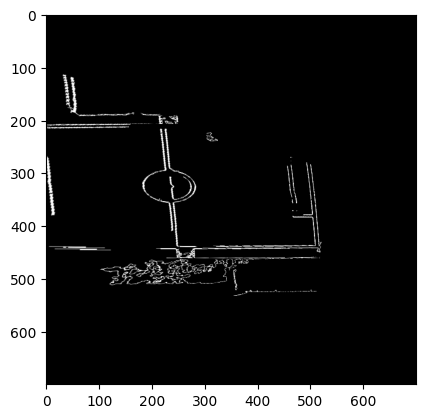

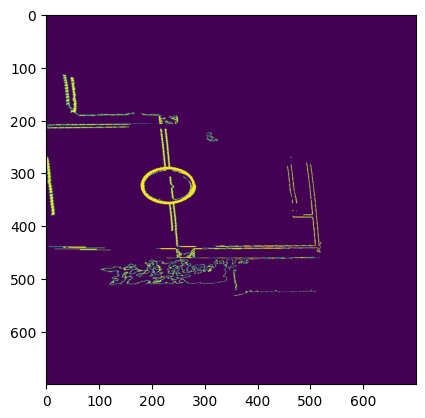

In [76]:
# from randomizedHoughEllipseDetection import FindEllipseRHT
import time
import cv2
import matplotlib.pyplot as plt
import numpy as np

path = "D:\\1LAB"
original_image_path = "../tmp/hehe8.png"
original_image = cv2.imread(original_image_path)  #"../tmp/v5_bacground.png"
# print(original_image.shape)
# original_image = cv2.blur(original_image, (5, 5))

from image_tuner import rgb_tune_from_params
# original_image = rgb_tune_from_params(original_image, 216, 212, 204, 255, 255, 255)  # 128, 167, 196, 255, 255, 255)
# original_image = cv2.resize(original_image, (256,256), interpolation=cv2.INTER_LINEAR)
# original_image = cv2.blur(original_image, (3, 3))
# print(original_image)
plt.figure()
plt.imshow(original_image)
plt.show()
original_image = cv2.cvtColor(original_image,cv2.COLOR_RGB2GRAY)
# mask = cv2.imread(path + "\\1619_mask.png", 0)
mask_binary = np.zeros(original_image.shape, dtype=bool)
mask_binary[original_image == 255] = False
mask_binary[original_image != 255] = True

time1 = time.time()
test = FindEllipseRHT(original_image, mask_binary)
# plt.figure()
# plt.imshow(original_image)
# plt.show()
test.max_iter = 200000
test.score_threshold = 10
data = test.run(plot_mode=False, debug_mode=False)

# data = data.tolist()
# data = sorted(data, key=lambda item: -item[5])
best_id = 0
best_metric = -1e9
# for i in range(len(data)):
#     tmp_metric = (1e6* data[i][5]+metric_by_points(data[i][0], data[i][1], data[i][2], data[i][3], data[i][4], original_image) /math.sqrt(data[i][2]*data[i][3]))
#     if tmp_metric > best_metric:
#         best_metric = tmp_metric
#         best_id = i
data[0] = data[best_id]
best = data[0][0]
for i in range(len(best)):
    best[i] = int(best[i])
delta = 0.2
# original_image*=0
# original_image+=255
# original_image = cv2.ellipse(original_image, best[0:2], (int(best[2] * (1 - delta)), int(best[3] * (1 - delta))),
#                              data[0][0][4], 0, 360, (0, 0, 0), -1)
# mask = cv2.ellipse(np.zeros_like(original_image), best[0:2], (int(best[2] * (1 + delta)), int(best[3] * (1 + delta))),
#                    data[0][0][4], 0, 360, (255, 255, 255), -1)
original_image = cv2.ellipse(original_image,list(map(lambda xx: int(xx),data[0][0][0:2])),list(map(lambda xx: int(xx),data[0][0][2:4])),data[0][0][4],0,360,(255,255,255),3)
# print(data,len(data))
# print("heheheeh")
plt.figure()
plt.imshow(original_image)
plt.show()


In [41]:
from numba import jit
# @jit(nopython=False)
def resize_image(image, new_size,dimensions = (0,1)):
    """
    Resize an image using bilinear interpolation.

    Parameters:
    image (numpy.ndarray): The input image as a NumPy array.
    new_size (tuple): The new size (width, height) of the image.

    Returns:
    numpy.ndarray: The resized image.
    """
    if dimensions != (0,1):
        raise NotImplementedError("not supported different dimesnions now: there is todo to do")
    old_height, old_width = image.shape[dimensions[0]],image.shape[dimensions[1]]
    new_height, new_width = new_size

    # Calculate the scaling factors
    height_scale = old_height / new_height
    width_scale = old_width / new_width
    new_shape = list(image.shape)
    new_shape[dimensions[0]] = new_height
    new_shape[dimensions[1]] = new_width

    # Create an empty array for the resized image
    resized_image = np.zeros(new_shape, dtype=image.dtype)

    for i in range(new_height):
        for j in range(new_width):
            # Calculate the corresponding coordinates in the original image
            x = i * height_scale
            y = j * width_scale

            # Get the integer and fractional parts
            x0, y0 = int(x), int(y)
            x1, y1 = min(x0 + 1, old_height - 1), min(y0 + 1, old_width - 1)

            # Calculate the weights for interpolation
            wx = x - x0
            wy = y - y0

            # Bilinear interpolation
            resized_image[i, j] = ( #todo: this code not interdimensional (i.e. only for dims = (0,1))
                (1 - wx) * (1 - wy) * image[x0, y0] +
                (1 - wx) * wy * image[x0, y1] +
                wx * (1 - wy) * image[x1, y0] +
                wx * wy * image[x1, y1]
            )

    return resized_image



Processing image: tmp.png
The number of output arc-support line segments: 70
The number of arc-support groups: 57
The number of initial ellipses: 18
The number of ellipse candidates: 12
edge pixel number: 10756
Edge image saved to output_edge_image.png
Gradient vectors saved to output_gradient_vectors.txt
Candidate ellipses saved to output_candidate_ellipses.txt
Processing complete.
(700, 700, 3)
228.73906749414564 29.89 20.48
(700, 700, 3)
235.1641147914368 28.12 19.22
(700, 700, 3)
228.9133340813202 43.12 26.91
(700, 700, 3)
228.50517186920604 44.87 27.99
(700, 700, 3)
229.81031028422296 47.34 28.37
(700, 700, 3)
233.78351188782977 53.11 31.51
(700, 700, 3)
230.87383252189622 26.96 23.28
(700, 700, 3)
231.04824186556834 25.96 20.15
(700, 700, 3)
230.4742115273844 113.24 57.08
(700, 700, 3)
229.060701446272 121.5 58.78
(700, 700, 3)
225.0066902675587 102.25 36.17
(700, 700, 3)
123.19222810738411 40.52 13.5


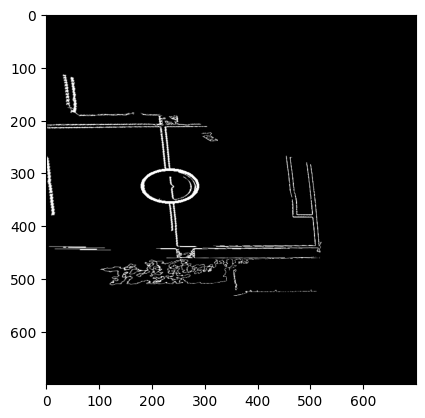

In [59]:
# lets try to find ellipse using code in c++(c)
from find_ellipse import find_ellipses_fast
img = cv2.imread("../tmp/hehe7.png")
ellipses = find_ellipses_fast(cv2.blur(img,(3,3)))
ordered = []
for i in ellipses:
    # metric = metric_by_points(i[0],i[1],i[2],i[3],i[4],cv2.cvtColor(img,cv2.COLOR_RGB2GRAY).astype(int))
    print(img.shape)
    metric = metric_by_mask(i[0],i[1],i[2],i[3],i[4],cv2.cvtColor(img,cv2.COLOR_RGB2GRAY).astype(np.uint8),width=3)
    ordered.append([i,metric])
ordered.sort(key=lambda x:-x[1])
for i in ordered[1:2]:
    i = i[0]
    img = cv2.ellipse(img,list(map(lambda xx: int(xx),i[0:2])),list(map(lambda xx: int(xx),i[2:4])),i[4],0,360,(255,255,255),3)
plt.figure()
plt.imshow(img)
plt.show()


In [13]:
input_video_path = "F:\\Videos\\2024-11-18 17-53-16.mkv"  #"F:\\Videos\\2024-11-18 17-59-05.avi"  #"F:\\Videos\\2024-11-18 17-49-57.mkv"  #"F:\\Videos\\2024-11-18 17-59-05.avi"

cap = cv2.VideoCapture(input_video_path)

output_video_path = '..\\tmp\\4_right_up_processed_last4.mp4'
from cut_image import get_cut_frame_from_frame

fps = cap.get(cv2.CAP_PROP_FPS)
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
ellipse_list_video = list()

fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Кодек для сохранения видео

# Создаем объект для записи нового видео
out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))
cntr = 0
while True:
    cntr += 1
    print(cntr)
    ret, image = cap.read()
    if not ret:
        break
    to_scale = 5
    image = get_cut_frame_from_frame(image, 2)
    image = cv2.rotate(image, cv2.ROTATE_180)
    image = cv2.blur(image, (2, 2))
    # image = cv2.blur(image, (2, 2))
    image_t = cluster_and_recolor(image, 11)
    print(image_t, type(image_t), type(image_t[0][0]), image_t.shape)
    # image_t = rgb_tune_from_params(image, 119, 151, 90, 146, 164, 134)#217, 213, 210, 237, 230,
    #223)  #201,199,198, 255, 255, 255)#253, 251, 250, 255, 255, 255)  #216, 212, 204, 255, 255, 255)
    # print(image_t,type(image_t),type(image_t[0][0]),image_t.shape)
    image_t = cv2.resize(image_t, (frame_width // to_scale, frame_width // to_scale), interpolation=cv2.INTER_LINEAR)
    image_t = cv2.blur(image_t, (5, 5))
    # cv2.imwrite("../tmp/hehe4.png", image)
    # break
    print(image_t.shape)
    test = FindEllipseRHT(image_t)
    test.max_iter = 200000
    data = test.run(plot_mode=True, debug_mode=False)
    # data[0][1]=data[0][1]*to_scale
    # data[0][2]=data[0][2]*to_scale
    # data[0][3]=data[0][3]*to_scale
    # data[0][0]=data[0][0]*to_scale
    ellipse_list_video.append(data[0])
    # for i in range(len(data[0])):
    #     ellipse_list_video[-1][i] = float(ellipse_list_video[-1][i])
    ellipse_list_video[-1] = list(map(int, ellipse_list_video[-1][0]))
    image_t = cv2.resize(image, (frame_width // to_scale, frame_width // to_scale), interpolation=cv2.INTER_LINEAR)
    clustered_frame = cv2.ellipse(image_t, ellipse_list_video[-1][0:2], ellipse_list_video[-1][2:4],
                                  ellipse_list_video[-1][4], 0, 360, color=(100, 100, 100), thickness=5)
    # cv2.imshow("hehe",clustered_frame)
    # cv2.waitKey()
    clustered_frame = cv2.resize(clustered_frame, (frame_width, frame_height), interpolation=cv2.INTER_LINEAR)

    out.write(clustered_frame)
    if cntr > 0:
        break
cap.release()
out.release()
cv2.destroyAllWindows()

1


In [ ]:
cap.release()
out.release()
cv2.destroyAllWindows()
print(ellipse_list_video)
for i in range(len(ellipse_list_video) - 10):
    for j in range(len(ellipse_list_video[i]) - 3):
        print(float(ellipse_list_video[i][j] - ellipse_list_video[i + 5][j]))

In [35]:
from image_tuner import tune_test

tune_test("../tmp/hehe4.png")  #27,32,32,167,207,162
from image_tuner import rgb_tune_test

# rgb_tune_test("../tmp/hehe4.png")
# from image_tuner import rgb_tune_from_params
# 
# original_image = rgb_tune_from_params(original_image, 128, 167, 196, 255, 255, 255)
# print("hf")
# plt.imshow(original_image)

68 27 89 105 77 255


below we will try to optimize ellipse we found further with gradient decent

In [ ]:
import math
import torch
import cv2

import matplotlib.pyplot as plt

# img = cv2.imread('../tmp/v5_bacground.png', cv2.IMREAD_COLOR)  # road.png is the filename
# generated = torch.randn(5)*100
# print(generated)
# img = img*0+100
# img = cv2.ellipse(img,(int(generated[0]+100),int(generated[1]+100)),(abs(int(generated[2])),abs(int(generated[3]))),float(generated[4]),0,360,color=(0,0,0),thickness=10)
# ksize = (60,60)
# for i in range(10):
#     img = cv2.blur(img,ksize=ksize)
# Convert the image to grayscale
# img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# image_torch = torch.from_numpy(img)
# print(image_torch)
# plt.imshow(img)
# cv2.imshow("eheh",img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
# center = torch.tensor([0.,0.], requires_grad=True)
# ax = torch.tensor(0., requires_grad=True)
# bx = torch.tensor(0., requires_grad=True)
# width = torch.tensor(0., requires_grad=True)
# params = torch.randn((5), requires_grad=True)


In [ ]:

# loss_BGD = []

In [ ]:
# x_0 = torch.randn((1), requires_grad=True)
# y_0 = torch.randn((1), requires_grad=True)
# angle = torch.randn((1), requires_grad=True)
# a = torch.randn((1), requires_grad=True)
# b = torch.randn((1), requires_grad=True)

In [54]:
import math
def points_on_ellipse(x_0, y_0, a, b, angle, n: int = 10):
    points = list()
    for i in range(n):
        point = (math.cos(i / math.pi / 2), math.sin(i / math.pi / 2))
        point = (point[0] * a, point[1] * b)
        point = (point[0] * math.cos(angle) + point[1] * math.sin(angle),
                 -point[0] * math.sin(angle) + point[1] * math.cos(angle))
        point = (point[0] + x_0, point[1] + y_0)
        points.append(point)
    return points


def points_on_line(from_x, from_y, to_x, to_y):
    ans = list()
    if math.fabs(from_x - to_x) > math.fabs(from_y - to_y):
        step_x = (to_x - from_x) / (to_y - from_y)
        for i in range(int(from_y), int(to_y) + 1, int((to_y - from_y) / math.fabs(to_y - from_y))):
            ans.append((int(step_x * i + from_x), int(i + from_y)))
    else:
        step_y = (to_y - from_y) / (to_x - from_x)
        for i in range(int(from_x), int(to_x) + 1, int((to_x - from_x) / math.fabs(to_x - from_x))):
            ans.append((int(i + from_x), int(step_y * i + from_y)))
    return ans


def points_on_line_v2(from_x, from_y, to_x, to_y, n_steps=None):
    if n_steps is None:
        return points_on_line(from_x, from_y, to_x, to_y)
    ans = list()
    step_x = (to_x - from_x) / n_steps
    step_y = (to_y - from_y) / n_steps
    for i in range(n_steps):
        ans.append((round(from_x + step_x * i), round(from_y + step_y * i)))
    return ans


def metric_by_points_(x_0, y_0, a, b, angle, data, n: int = 20): 
    points = points_on_ellipse(x_0, y_0, a, b, angle, n)
    ans = None
    cntr = 0
    for i in range(n):
        for j in points_on_line_v2(points[i][0], points[i][1], points[(i + 1) % n][0], points[(i + 1) % n][1],
                                   1 + round(max(abs(points[i][0] - points[(i + 1) % n][0]),
                                                 abs(points[i][0] - points[(i + 1) % n][0])))):
            if 0 <= j[0] < data.shape[0] and 0 <= j[1] < data.shape[1]:
                if ans is None:
                    ans = data[j[0]][j[1]]
                else:
                    ans += data[j[0]][j[1]]
                if data[j[0]][j[1]] == 0:
                    cntr +=1
                    # pass
    cntr*=0.3
    if ans is None:
        return cntr 
    return ans + cntr

def metric_by_mask(x_0, y_0, a, b, angle, data, width: int = 20):
    """
    this function constructs mask with form of ellipse,applies it to data and computes all white pixels
    this function cannot be used as loss
    assumed that max(data) gives max value for this data type so everything scaled down by factor of this value
    """
    import cv2
    # print(data.shape)
    data = cv2.resize(data,(500,500))#so thickness will not matter for same image
    max_point = data.max()
    #data/=max_point # this line replaced with /max_point in return statement for optimization
    mask = cv2.ellipse(np.zeros(data.shape).astype(np.uint8),[int(x_0),int(y_0)],[int(a),int(b)],angle,0,360,255,width)
    metric = np.sum(data[mask].astype(int))
    ellipse_perimeter = math.sqrt(a*a+b*b)# O(ellipse_perimeter_approximation)
    metric/=ellipse_perimeter
    print(metric/max_point,a,b)
    return metric/max_point
    

def metric_by_points(x_0, y_0, a, b, angle, data, n: int = 20):
    max_point = max(data)
    data/=max_point
    return metric_by_points_(x_0, y_0, a, b, angle, data, n)
    
def loss_by_points(x_0, y_0, a, b, angle, data, n: int = 20):
    raise NotImplementedError()
    import torch
    max_point = max(data)#todo:add here nograd or something 
    data/=max_point
    return metric_by_points_(x_0, y_0, a, b, angle, data, n)#todo check case where only cntr returned, try to wrap it into torch.tensor with 0 grad


In [ ]:
import copy


class TinyModel(torch.nn.Module):
    def __init__(self, x_0, y_0, a, b, angle):
        super(TinyModel, self).__init__()

        self.x_0 = torch.nn.Parameter(torch.tensor(x_0, requires_grad=True))
        self.y_0 = torch.nn.Parameter(torch.tensor(y_0, requires_grad=True))
        self.angle = torch.nn.Parameter(torch.tensor(angle, requires_grad=True))
        self.a = torch.nn.Parameter(torch.tensor(a, requires_grad=True))
        self.b = torch.nn.Parameter(torch.tensor(b, requires_grad=True))
        self.loss_BGD = []

    def convert(self, px_0, py_0, pangle, pa, pb):  #ax**2+bx+cy**2+dy+exy+f = 0
        # if abs(pa)<eps:
        #     pa += eps * torch.sign(pa)
        # if abs(pb)<eps:
        #     pb += eps * torch.sign(pb)
        s_ang = torch.sin(pangle)
        c_ang = torch.cos(pangle)
        return torch.stack(
            [c_ang ** 2 / pa ** 2 + s_ang ** 2 / pb ** 2, 2 * (c_ang * px_0 / pa ** 2 + s_ang * py_0 / pb ** 2),
             s_ang ** 2 / pa ** 2 + c_ang ** 2 / pb ** 2, 2 * (-s_ang * px_0 / pa ** 2 + c_ang * py_0 / pb ** 2),
             2 * (c_ang * s_ang) * (-1 / pa ** 2 + 1 / pb ** 2),
             (px_0 / pa) ** 2 + (py_0 / pb) ** 2])  # maybe -1 to the last one

    # params = 0
    def forward(self, x):
        # global params
        params = self.convert(self.x_0, self.y_0, self.angle, self.a, self.b)
        return torch.einsum('ij,j->i', x, params)


class Model:

    def __init__(self, x_0, y_0, a, b, angle):
        self.model = TinyModel(x_0, y_0, a, b, angle)
        self.eps = 1e-5
        self.loss_BGD = []
        self.metric_BGD = []
        self.best_loss = 1e30
        self.best_metric = 1e-30

    # 
    def loss_c(self, val, X_v):
        perimeter = math.pi * torch.sqrt((self.model.a ** 2 + self.model.b ** 2) * 2)
        # val =(val + 1 / (
        #         self.eps + val))-2

        return torch.sqrt(torch.sum(
            val * X_v)) + perimeter + self.model.angle ** 2 * 0.3  # +self.model.a**2+self.model.b**2+self.model.angle**2 

    # def loss_c(val):
    #     return torch.sum(val**2)**(0.2)#+torch.sum(params**3)

    # xs = torch.randn((5, 5))
    # print(loss_c(forward(xs)))
    def solve(self, img, debug=False, n_steps=1000, loss_fn=None, metric_fn=None):
        if loss_fn is not None:
            self.loss = loss_fn
        else:
            def tmp(a, b, c):
                return self.loss_c(b, c)

            self.loss = tmp
        self.optim = torch.optim.Adam(self.model.parameters(), lr=0.1)
        X_v = torch.from_numpy(cv2.cvtColor(img, cv2.COLOR_BayerGR2GRAY)).type(torch.float64)
        # print(X_v)
        X_1 = torch.stack([torch.ones((X_v.shape[0])) * size for size in range(0, X_v.shape[1])]).type(torch.float64)
        #X_1 -= X_v.shape[1]//2
        X_2 = torch.stack([torch.ones((X_v.shape[1])) * size for size in range(0, X_v.shape[0])]).type(torch.float64)
        #X_2 -= X_v.shape[0]//2
        X_2 = torch.transpose(X_2, 0, 1)
        if debug:
            print(X_1, X_2)
        # print(X_1.shape, X_2.shape)
        X_1 = torch.flatten(X_1)
        X_2 = torch.flatten(X_2)
        X_v = torch.flatten(X_v)
        X_v = X_v - torch.min(X_v)
        # X_v = torch.max(X_v) - X_v
        X = torch.stack([X_1 ** 2, X_1, X_2 ** 2, X_2, X_1 * X_2, torch.ones_like(X_1)])
        if debug:
            print(X)
        X = torch.transpose(X, 0, 1)
        loss = self.loss(self, self.model.forward(X), X_v)
        self.best_loss = 1e20
        self.best_model = copy.deepcopy(self.model)
        for i in range(n_steps):
            # making predictions with forward pass
            Y = self.model.forward(X)
            # calculating the loss between original and predicted data points
            loss = self.loss(self, Y, X_v)
            if metric_fn is not None:
                self.metric_BGD.append(
                    metric_fn(float(self.model.x_0), float(self.model.y_0), float(self.model.a), float(self.model.b),
                              float(self.model.angle), img))
            if debug:
                print(torch.min(Y))
                if torch.min(Y) < -0.1:
                    print(
                        "bbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbb")
            # storing the calculated loss in a list
            self.loss_BGD.append(loss.item())
            # backward pass for computing the gradients of the loss w.r.t to learnable parameters
            loss.backward()
            self.optim.step()
            self.optim.zero_grad()
            if i % 10 == 0 and debug:
                print(loss, " is loss")
                print(float(self.model.x_0), float(self.model.y_0), float(self.model.angle), float(self.model.a),
                      float(self.model.b), " is params")
            if loss < self.best_loss and metric_fn is None:
                self.best_loss = float(loss)
                self.best_model = copy.deepcopy(self.model)
            elif metric_fn is not None and self.metric_BGD[-1] > self.best_metric:
                self.best_model = copy.deepcopy(self.model)
                self.best_metric = self.metric_BGD[-1]
        # self.model = self.best_model
        return self.best_loss



In [ ]:

val = 1
val = float((torch.randn((1)))) * 0.3 + 0.5

In [ ]:
best_metric = 1e9
best_enum = 0
print(val)
for enum in range(int(len(data) * 0.9 * val), int(len(data) * 0.9 * val) + 10):
    if enum >= len(data):
        break
    i = data[enum]
    md = Model(i[0], i[1], i[2], i[3], i[4])
    metric = float(md.solve(original_image, n_steps=100))
    print(metric)
    if metric < best_metric:
        best_metric = metric
        best_enum = enum
# best_enum = 0
print(best_enum)
best_md = Model(data[best_enum][0], data[best_enum][1], data[best_enum][2], data[best_enum][3], data[best_enum][4])
best_md.solve(original_image, n_steps=1000, debug=False, metric_fn=metric_by_points)

In [ ]:

from functools import partial

# ax = plt.plot(loss_BGD, label="Batch Gradient Descent")
img = cv2.imread(original_image_path)
# img = original_image
fig, ax = plt.subplots()
# best_md.model = best_md.best_model
model = best_md.best_model
ax.plot(best_md.loss_BGD)
plt.plot(best_md.metric_BGD)
print(best_md.metric_BGD)
print(model.x_0, model.y_0, model.a, model.b, model.angle)
# plt.xlabel('Epoch')
# plt.ylabel('Cost/Total loss')
# plt.legend()

# ax.set_yscale('function', functions=(partial(np.power, 10.0), np.log10))
# ax.set(xlim=(1,2000),ylim=(10,100))

# ax.set_yticks([1, 3, 3.5, 3.75, 4.0])
plt.show()

image = cv2.ellipse(img, (int(model.x_0), int(model.y_0)),
                    (abs(int(model.a)), abs(int(model.b))), float(model.angle), 0, 360,
                    color=(0, 0, 0))
# image = cv2.ellipse(img,(int(data[best_enum][0]),int(data[best_enum][1])),(abs(int(data[best_enum][2])),abs(int(data[best_enum][3]))),float(data[best_enum][4]),0,360,color=(0,0,0))
# print(image.shape)
print(type(image))
# image = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
plt.imshow(image)

так как модель расходится необходимо выбрать лосс, на котором все будет сходится

In [ ]:
losses = list()
codes = list()
cntr = 0
for perim in "+/":
    for val_n1 in ("#", ""):
        for val_n2 in ("#", ""):
            lossfn = \
                f"""
def loss{cntr}(self, val, X_v):
    perimeter = math.pi * torch.sqrt((self.model.a ** 2 + self.model.b ** 2) * 2)
    {val_n1}val = val + 1/(self.eps+val) {val_n2} -2 +self.eps
    return torch.sqrt(torch.sum(val * X_v))  {perim} perimeter
losses.append(loss{cntr})
""";
            cntr += 1;
            exec(lossfn);
            codes.append(lossfn)
print(losses)

In [ ]:
best_metric_max_value = -1e30
best_metric_id = 0
for i in range(len(losses)):
    best_md = Model(data[best_enum][0], data[best_enum][1], data[best_enum][2], data[best_enum][3], data[best_enum][4])
    best_md.solve(original_image, n_steps=1000, debug=False, metric_fn=metric_by_points, loss_fn=losses[i])
    current_best = -1e30
    current_best_id = 0
    for j in best_md.metric_BGD:
        if current_best < j:
            current_best = j
    if best_metric_max_value < current_best:
        best_metric_max_value = current_best
        best_metric_id = current_best_id
    print(best_metric_max_value, current_best, "current best")
print(codes[best_metric_id])

camera position recounting

In [ ]:

import math


def ellipse_tangent_points(ex, ey, ea, eb, eang, a, b):
    if a == 0 and b == 0:
        return ()

    y_0 = b * ea / math.sqrt(eb ** 4 + ea ** 4)
    x_0 = a * ea / math.sqrt(eb ** 4 + ea ** 4)
    x_0, y_0 = math.cos(eang) * x_0 + math.sin(eang) * y_0, -math.sin(eang) * x_0 + math.cos(eang) * y_0
    return ((x_0 + ex, y_0 + ey), (-x_0 + ex, -y_0 + ey))  #todo: fix: line should also rotate in the beginning


def recount_camera_position(ex, ey, ea, eb, eang):
    #constants
    point_dist = None
    pixel_distance = None
    real_radius = None

    axis_direction = (math.sin(eang) * eb, math.cos(eang) * eb)

    #to compute
    distance_to_camera = None
    height_of_camera = None
    horizontal_move = None

    #todo: assuming this, which is not always true
    vertical_angle_of_camera = 0
    horizontal_angle_of_camera = 0
    rotation_of_camera = 0

    return (distance_to_camera, height_of_camera, horizontal_move, vertical_angle_of_camera, horizontal_angle_of_camera,
            rotation_of_camera)






In [ ]:
# AI -generated
# TODO: test this cell

import cv2
import numpy as np


def detect_central_circle(image_path):
    # Load the image
    image = cv2.imread(image_path)
    if image is None:
        print("Error: Image not found")
        return
    height, width = image.shape[:2]

    # Convert to HSV color space for better color segmentation
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Define range for white color (field markings)
    lower_white = np.array([0, 0, 200])
    upper_white = np.array([180, 30, 255])
    mask = cv2.inRange(hsv, lower_white, upper_white)

    # Apply morphological operations to reduce noise
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    # Find edges using Canny detector
    edges = cv2.Canny(mask, 50, 150)

    # Find contours in the edge map
    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    best_ellipse = None
    max_area = 0

    for contour in contours:
        # Skip small contours
        if len(contour) < 5:
            continue

        # Fit ellipse to the contour
        ellipse = cv2.fitEllipse(contour)
        (center, axes, angle) = ellipse
        major_axis = max(axes)
        minor_axis = min(axes)

        # Calculate ellipse area and aspect ratio
        area = np.pi * (major_axis / 2) * (minor_axis / 2)
        aspect_ratio = major_axis / minor_axis if minor_axis != 0 else 0

        # Filter based on area, aspect ratio, and position
        if (area > 500 and
                0.5 < aspect_ratio < 3 and
                (width * 0.3 < center[0] < width * 0.7) and
                (height * 0.3 < center[1] < height * 0.7)):

            if area > max_area:
                max_area = area
                best_ellipse = ellipse

    # Draw the detected ellipse and its center
    if best_ellipse is not None:
        cv2.ellipse(image, best_ellipse, (0, 255, 0), 2)
        center = (int(best_ellipse[0][0]), int(best_ellipse[0][1]))
        cv2.circle(image, center, 5, (0, 0, 255), -1)

    # Display the result
    cv2.imshow("hehe", image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

